# 01 — Behavioural feature engineering

Turn the OHLCV master into one row per stock describing **how it trades**: risk, market
sensitivity, trend, downside and liquidity.

The output of this notebook (`data/processed/features.parquet`) is the input to
[`02_clustering.ipynb`](02_clustering.ipynb).

Three decisions get made here, and each one is a place the analysis could quietly go wrong:

1. **Which window** to measure over — long enough for stable estimates, short enough to keep the universe.
2. **Which symbols** qualify — features are only comparable if every stock traded through the window.
3. **What to do with impossible returns** — unadjusted corporate actions masquerading as behaviour.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.features import (CORPORATE_ACTION_THRESHOLD, build_features,
                          daily_returns, select_universe)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="deep")

prices = pd.read_parquet("../data/raw/nifty500_ohlcv_raw.parquet")
constituents = pd.read_csv("../data/raw/nifty500_constituents.csv")

print(f"{len(prices):,} rows | {prices['symbol'].nunique()} symbols "
      f"| {prices['date'].min().date()} to {prices['date'].max().date()}")

526,815 rows | 504 symbols | 2022-01-03 to 2026-09-04


## 1. Choosing the window

Longer windows give more stable volatility and drawdown estimates, but drop every stock that
listed recently. The Nifty 500 has a lot of recent listings, so this is a real trade-off rather
than a formality — worth quantifying instead of guessing.

In [2]:
end = prices["date"].max()
rows = []
for years in [1, 2, 3, 4]:
    window = prices[prices["date"] >= end - pd.DateOffset(years=years)]
    sessions = window["date"].nunique()
    bars = window.groupby("symbol")["date"].count()
    rows.append({
        "window": f"{years}y",
        "sessions": sessions,
        "symbols >=90% covered": int((bars >= sessions * 0.90).sum()),
        "symbols >=95% covered": int((bars >= sessions * 0.95).sum()),
    })

pd.DataFrame(rows).set_index("window")

,sessions,symbols >=90% covered,symbols >=95% covered
window,,,
1y,252,486,485
2y,501,463,457
3y,745,444,438
4y,993,427,422


**Chosen: a 3-year window at >=95% coverage — 438 of 504 symbols.**

Three years spans roughly 745 sessions, which comfortably supports a 12-month momentum feature
and leaves enough observations for skew and kurtosis to mean something. Going to 4 years buys
little extra stability and costs another 16 symbols; dropping to 1 year would keep 485 symbols
but make the 12-month momentum feature degenerate.

The 66 excluded symbols are recent IPOs, not failures — they are listed in the pipeline's
`coverage_report.csv` and re-enter the analysis automatically once they have three years of history.

In [3]:
window, kept, dropped = select_universe(prices, window_years=3, min_coverage=0.95)

print(f"window : {window['date'].min().date()} to {window['date'].max().date()}")
print(f"kept   : {len(kept)} symbols")
print(f"dropped: {len(dropped)} symbols (insufficient history)")
print("\nexamples of dropped symbols:", ", ".join(sorted(dropped)[:8]))

window : 2023-09-04 to 2026-09-04
kept   : 438 symbols
dropped: 66 symbols (insufficient history)

examples of dropped symbols: AADHARHFC, ABDL, ABLBL, ACMESOLAR, AEGISVOPAK, AFCONS, AIIL, ANTHEM


## 2. Impossible returns

Prices come from Yahoo with `auto_adjust=True`, which handles most splits and dividends — but
not all of them. A handful of sessions show single-day moves that no index constituent actually
makes. These are unadjusted corporate actions.

They matter far out of proportion to their count: kurtosis is a fourth-moment statistic, so one
bad point can define a stock's entire "tail behaviour" feature.

In [4]:
raw_returns = daily_returns(window, mask_corporate_actions=False)

suspects = (raw_returns[raw_returns.abs() > CORPORATE_ACTION_THRESHOLD]
            .stack()
            .rename("return")
            .reset_index()
            .sort_values("return"))

print(f"{len(suspects)} sessions beyond +/-{CORPORATE_ACTION_THRESHOLD:.0%} "
      f"out of {int(raw_returns.notna().sum().sum()):,} observations "
      f"({len(suspects) / raw_returns.notna().sum().sum():.4%})")
suspects

7 sessions beyond +/-40% out of 325,661 observations (0.0021%)


,date,symbol,return
4,2025-06-16,ZFCVINDIA,-0.834466
1,2024-01-01,GPIL,-0.795032
0,2024-01-01,CGCL,-0.748295
2,2024-01-01,MOTILALOFS,-0.746132
3,2025-05-22,ABFRL,-0.665923
6,2026-04-30,VEDL,-0.648979
5,2025-10-14,TMPV,-0.401513


Each of these is a known corporate event — Vedanta's 2026 demerger, GPIL's bonus issue,
ZF Commercial Vehicles' split — not a day when the stock genuinely lost most of its value.

Masking them is a deliberately minimal intervention: it discards **0.002%** of observations
and leaves everything else untouched.

In [5]:
returns = daily_returns(window, mask_corporate_actions=True)

comparison = pd.DataFrame({
    "raw": [raw_returns.kurtosis().max(), raw_returns.kurtosis().median(),
            raw_returns.skew().min()],
    "masked": [returns.kurtosis().max(), returns.kurtosis().median(),
               returns.skew().min()],
}, index=["max kurtosis", "median kurtosis", "min skew"])

comparison.round(2)

,raw,masked
max kurtosis,331.32,43.54
median kurtosis,4.43,4.34
min skew,-14.57,-3.67


Peak kurtosis falls from **331 to 44** and the worst skew from **-14.6 to -3.7**, while the
median barely moves. That is the signature of removing artifacts rather than removing signal:
the typical stock is unaffected, and only the corrupted ones change.

## 3. The feature set

Ten features, chosen to describe behaviour along axes a sector label does not capture:

| Feature | Captures |
|---|---|
| `ann_volatility` | overall risk level |
| `downside_volatility` | risk that actually hurts — dispersion of losing days only |
| `beta` | sensitivity to the market, vs an equal-weight index built from the universe itself |
| `mom_3m`, `mom_6m`, `mom_12m` | trend persistence across horizons |
| `max_drawdown` | worst peak-to-trough loss |
| `return_skew` | asymmetry — does it grind up and crash, or vice versa |
| `return_kurtosis` | fat tails — how often extreme days happen |
| `log_turnover` | liquidity tier; logged because turnover spans orders of magnitude |

The market proxy is built from the universe rather than loaded from an external benchmark file,
so it can never drift out of sync with the price master.

In [6]:
features = build_features(prices, window_years=3, min_coverage=0.95)

print(f"{features.shape[0]} symbols x {features.shape[1]} features")
print(f"window: {features.attrs['window_start']} to {features.attrs['window_end']}")
print(f"masked observations: {features.attrs['masked_observations']}")
print(f"nulls: {int(features.isna().sum().sum())}")

features.head()

438 symbols x 10 features
window: 2023-09-04 to 2026-09-04
masked observations: 7
nulls: 0


,ann_volatility,downside_volatility,beta,mom_3m,mom_6m,mom_12m,max_drawdown,return_skew,return_kurtosis,log_turnover
symbol,,,,,,,,,,
360ONE,0.365794,0.218407,0.950896,0.057674,0.074610,0.121601,-0.376672,0.222390,0.831242,8.773112
3MINDIA,0.292110,0.150393,0.601689,0.048314,-0.035022,0.064728,-0.350772,2.371288,17.737447,8.091701
AARTIIND,0.373547,0.253460,1.335827,0.117280,0.173363,0.276560,-0.548053,0.381782,6.905308,8.715422
AAVAS,0.302154,0.173843,0.661556,0.037632,0.062139,-0.185384,-0.516370,0.797999,2.954888,8.383513
ABB,0.333376,0.227394,1.014197,0.081696,0.241817,0.450909,-0.481100,0.232432,4.716855,9.221323


In [7]:
features.describe().T[["mean", "std", "min", "50%", "max"]].round(3)

,mean,std,min,50%,max
ann_volatility,0.361,0.088,0.186,0.351,0.623
downside_volatility,0.226,0.053,0.125,0.220,0.396
beta,1.000,0.357,0.233,0.981,1.923
mom_3m,0.057,0.149,-0.233,0.041,0.841
mom_6m,0.130,0.280,-0.616,0.075,2.323
mom_12m,0.083,0.369,-0.546,0.006,2.233
max_drawdown,-0.433,0.128,-0.795,-0.423,-0.150
return_skew,0.413,0.741,-3.671,0.421,2.634
return_kurtosis,5.549,4.656,-0.112,4.337,43.540
log_turnover,8.842,0.489,7.508,8.830,10.351


`beta` has a mean of exactly 1.00 — which it must, since the market proxy is the equal-weight
average of these same stocks. That is a useful built-in check that the computation is wired up
correctly.

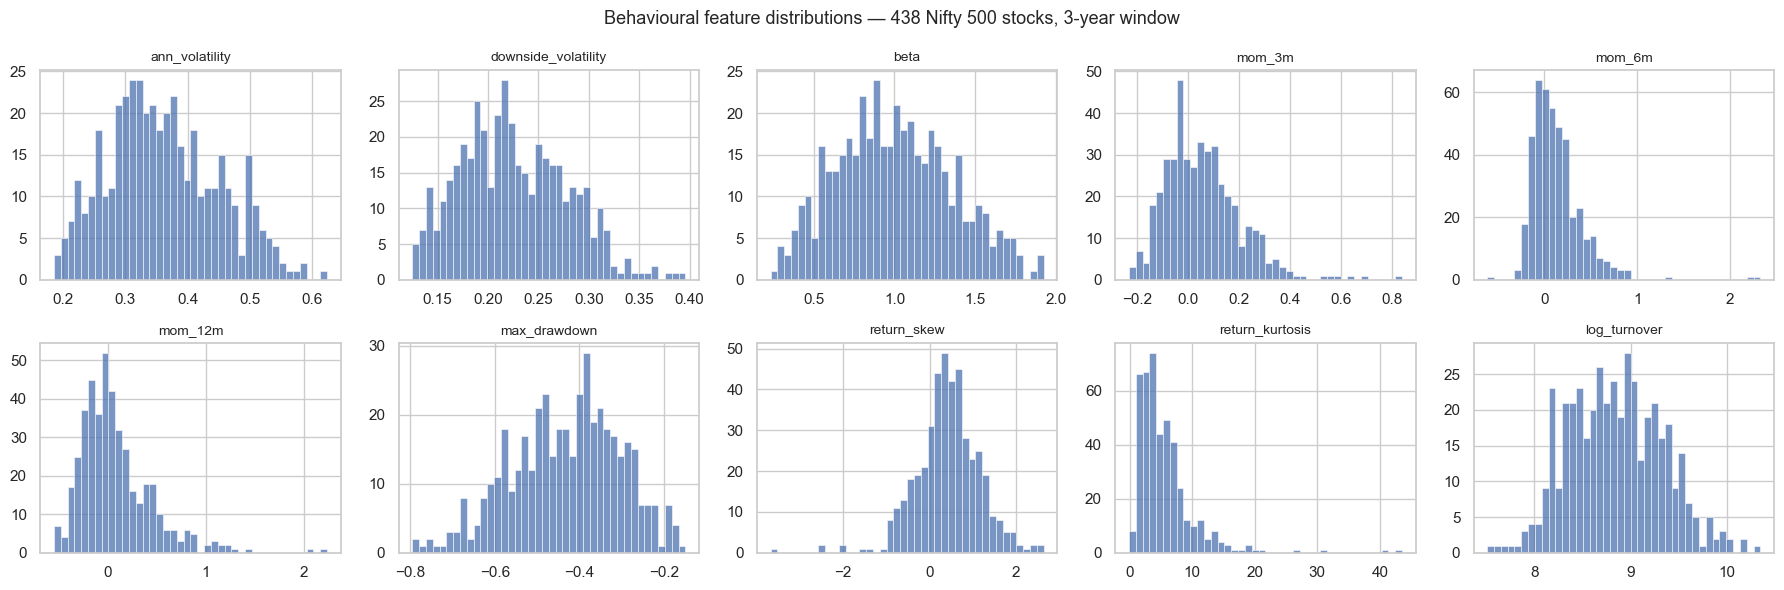

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, column in zip(axes.ravel(), features.columns):
    sns.histplot(features[column], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(column, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Behavioural feature distributions — 438 Nifty 500 stocks, 3-year window",
             fontsize=13)
fig.tight_layout()
plt.show()

## 4. What the features share

Volatility, downside volatility, beta and drawdown all measure overlapping aspects of risk.
Feeding four correlated columns into a distance-based clustering algorithm silently weights risk
four times as heavily as liquidity — which is the argument for a PCA step in the next notebook.

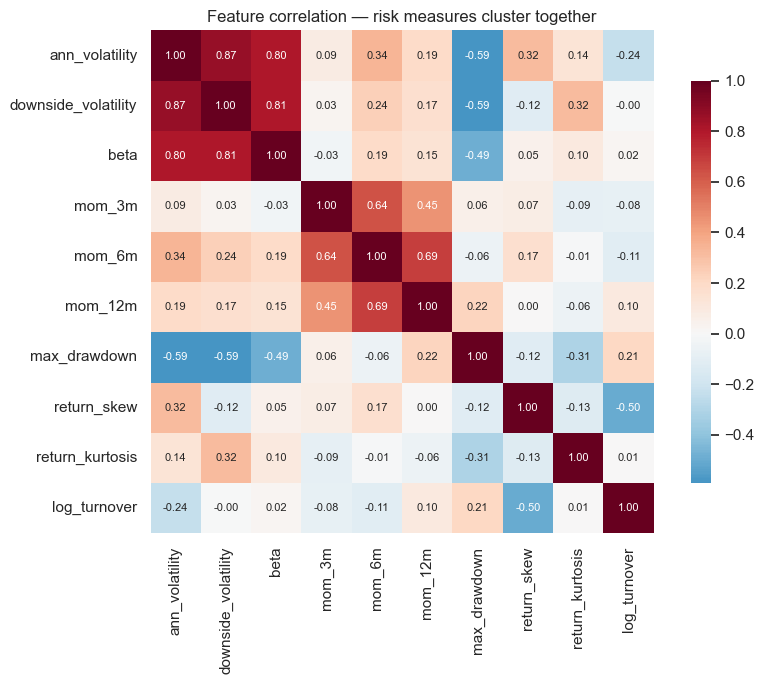

In [9]:
correlation = features.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Feature correlation — risk measures cluster together", fontsize=12)
fig.tight_layout()
plt.show()

In [10]:
upper = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
strongest = (upper.stack().rename("correlation").reset_index()
             .assign(abs_corr=lambda d: d["correlation"].abs())
             .sort_values("abs_corr", ascending=False)
             .head(6)[["level_0", "level_1", "correlation"]])
strongest.round(3)

,level_0,level_1,correlation
0,ann_volatility,downside_volatility,0.869
9,downside_volatility,beta,0.806
1,ann_volatility,beta,0.803
30,mom_6m,mom_12m,0.693
24,mom_3m,mom_6m,0.639
13,downside_volatility,max_drawdown,-0.591


`ann_volatility` and `downside_volatility` are almost the same measurement, and `max_drawdown`
tracks both. PCA in the next notebook collapses this redundancy so that clustering is not
dominated by whichever concept happens to have the most columns.

## 5. Persist

In [11]:
features.to_parquet("../data/processed/features.parquet")
print(f"wrote ../data/processed/features.parquet — {features.shape[0]} rows")

wrote ../data/processed/features.parquet — 438 rows
